In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, roc_auc_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('dataset/credit_risk.csv')
df.drop('Id', axis=1, inplace=True)
df.head()

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


- EDA

In [3]:
print(f"Shape of the data: {df.shape[0]} rows and {df.shape[1]} columns")

Shape of the data: 32581 rows and 11 columns


In [4]:
print(f"Missing values in each column:\n{df.isnull().sum()}")

Missing values in each column:
Age                  0
Income               0
Home                 0
Emp_length         895
Intent               0
Amount               0
Rate              3116
Status               0
Percent_income       0
Default              0
Cred_length          0
dtype: int64


In [5]:
print(f"Statistical Distribution of numerical columns:")
df.describe()

Statistical Distribution of numerical columns:


,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [6]:
cat_cols = df[df.select_dtypes(include=['object']).columns]

for col in cat_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

Value counts for Home:
Home
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

Value counts for Intent:
Intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Value counts for Default:
Default
N    26836
Y     5745
Name: count, dtype: int64



In [7]:
df.Status.value_counts()

Status
0    25473
1     7108
Name: count, dtype: int64

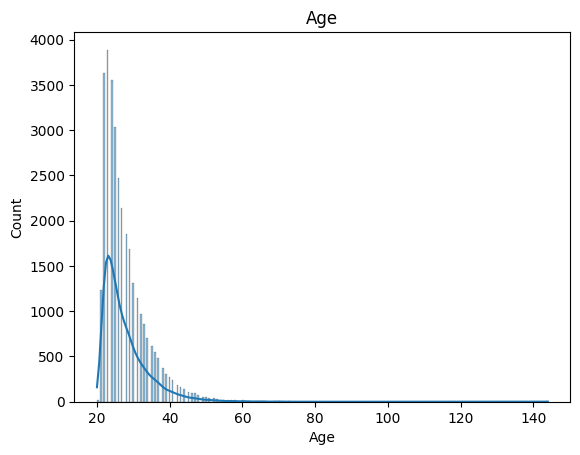

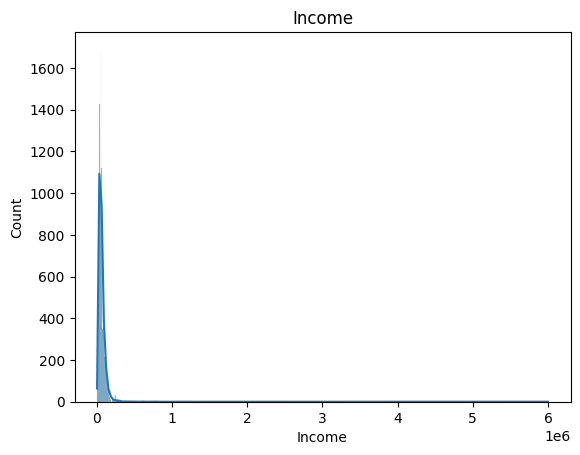

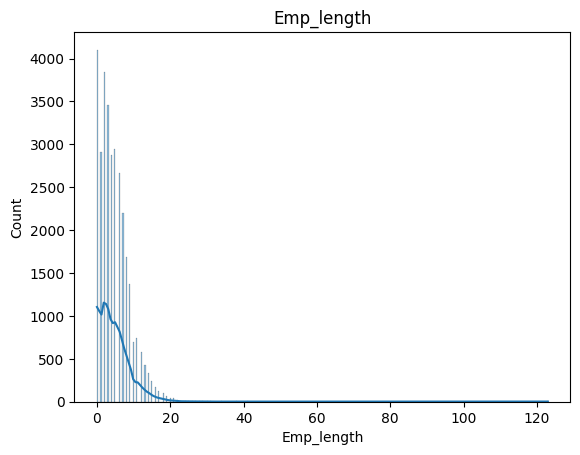

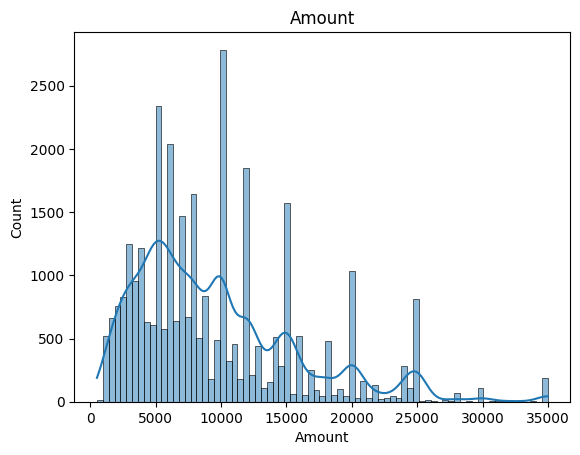

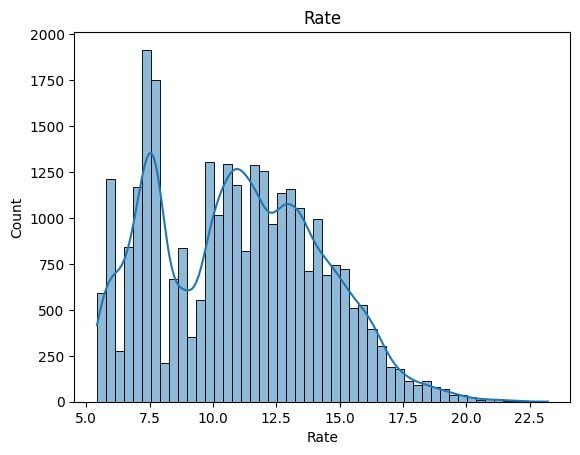

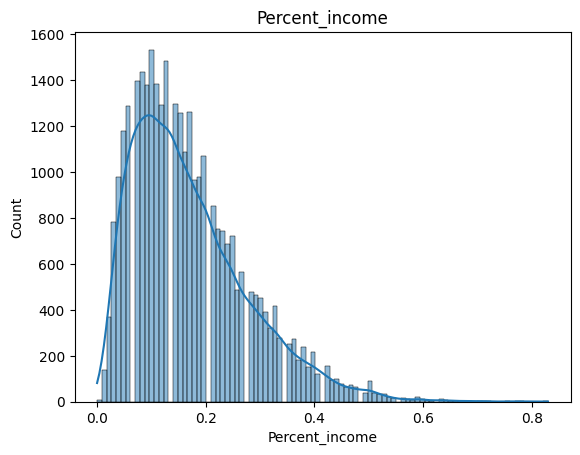

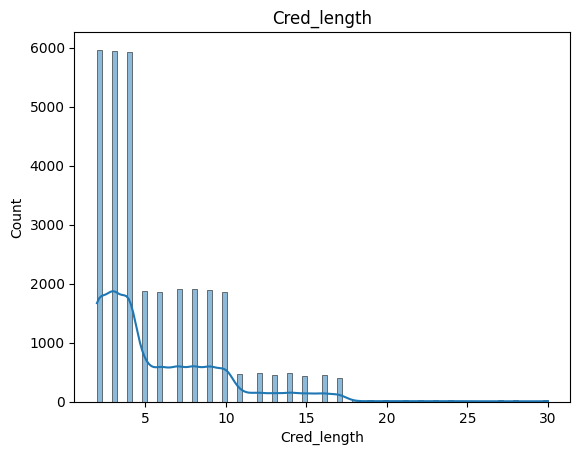

In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if col != 'Status':
        sb.histplot(df[col], kde=True)
        plt.title(col)
        plt.show()
        plt.savefig(f'charts/{col}_distribution.png')
        plt.close()

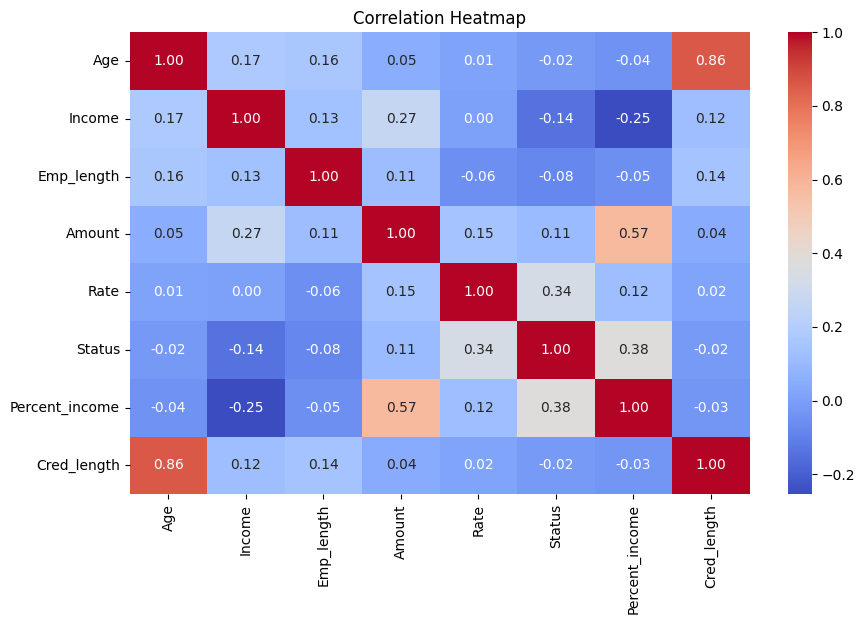

In [9]:
corr_df = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sb.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
plt.savefig('charts/correlation_heatmap.png')
plt.close()

Data Preprocessing

In [10]:
df.Emp_length.fillna(df['Emp_length'].mean(), inplace=True)
df.Rate.fillna(df['Rate'].mean(), inplace=True)

print(f'Missing values after imputation:\n{df.isnull().sum()}')

Missing values after imputation:
Age               0
Income            0
Home              0
Emp_length        0
Intent            0
Amount            0
Rate              0
Status            0
Percent_income    0
Default           0
Cred_length       0
dtype: int64


C:\Users\Hp\AppData\Local\Temp\ipykernel_6368\2123458983.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Emp_length.fillna(df['Emp_length'].mean(), inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_6368\2123458983.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

- Encode categories

In [11]:
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,22,59000,3,123.0,4,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,1,1000,11.14,0,0.10,0,2
2,25,9600,0,1.0,3,5500,12.87,1,0.57,0,3
3,23,65500,3,4.0,3,35000,15.23,1,0.53,0,2
4,24,54400,3,8.0,3,35000,14.27,1,0.55,1,4


- Address target class imbalance

In [12]:
df_0 = df[df['Status'] == 0]
df_1 = df[df['Status'] == 1]

count_0, count_1 = df['Status'].value_counts()

In [13]:
df_1_over = df_1.sample(count_0, replace=True, random_state=42)
df_over = pd.concat([df_0, df_1_over], axis=0)
df_over['Status'].value_counts()

Status
0    25473
1    25473
Name: count, dtype: int64

In [14]:
x = df_over.drop('Status', axis=1)
y = df_over['Status']

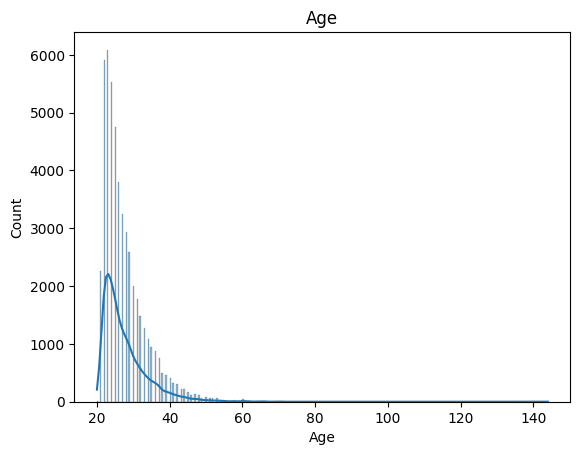

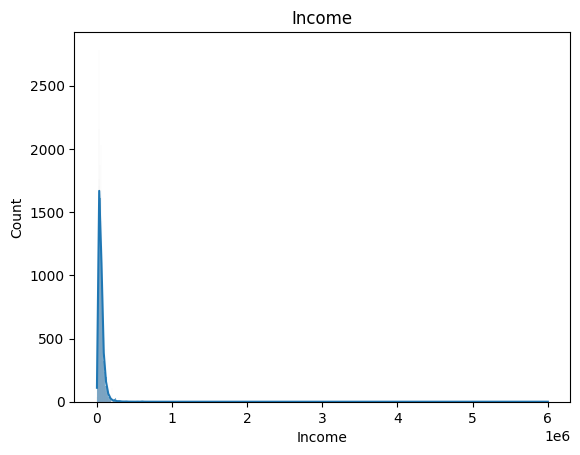

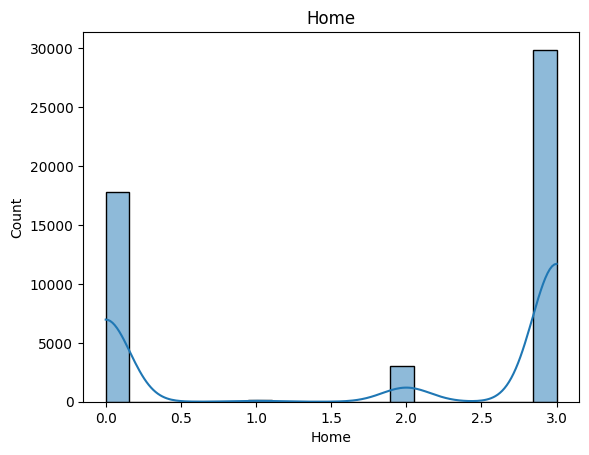

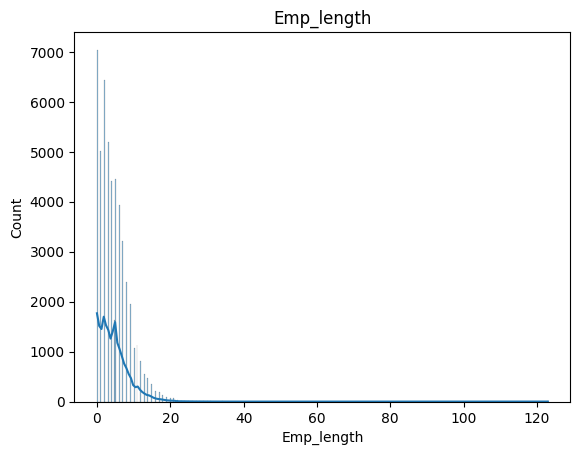

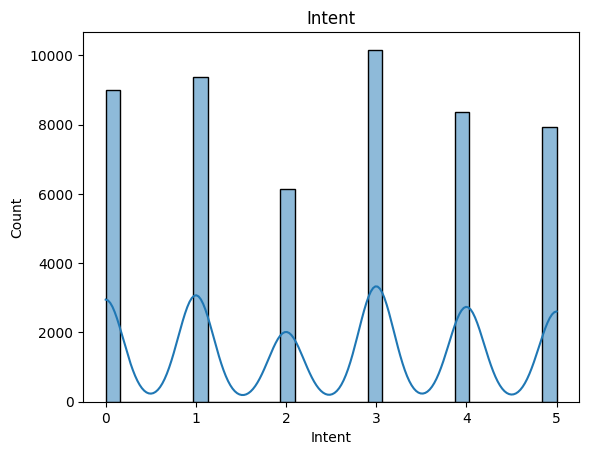

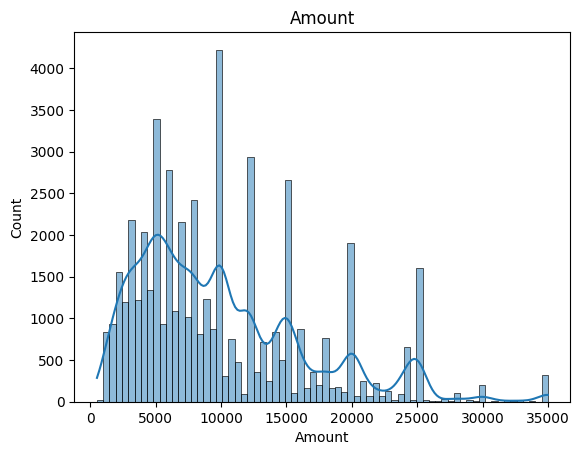

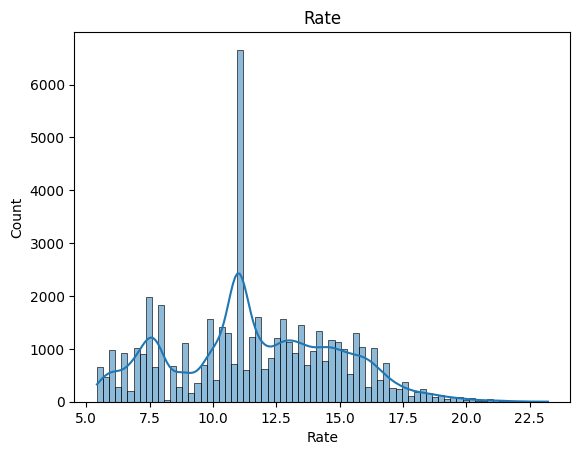

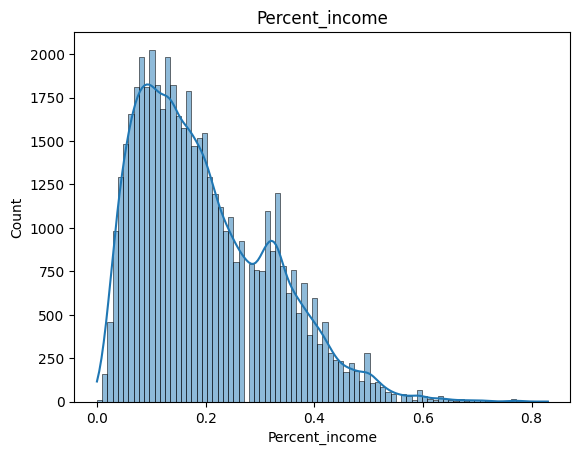

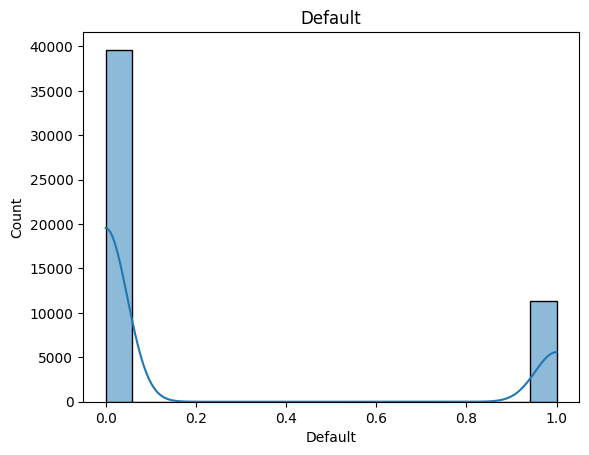

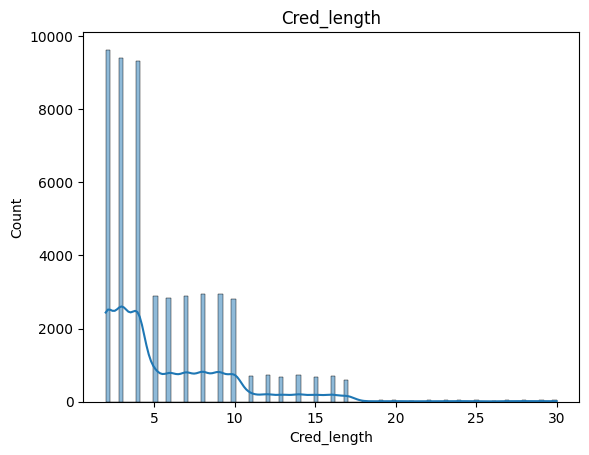

In [15]:
for col in x:
        sb.histplot(x[col], kde=True)
        plt.title(col)
        plt.show()
        plt.savefig(f'charts/{col}_oversampled_data_distribution.png')
        plt.close()

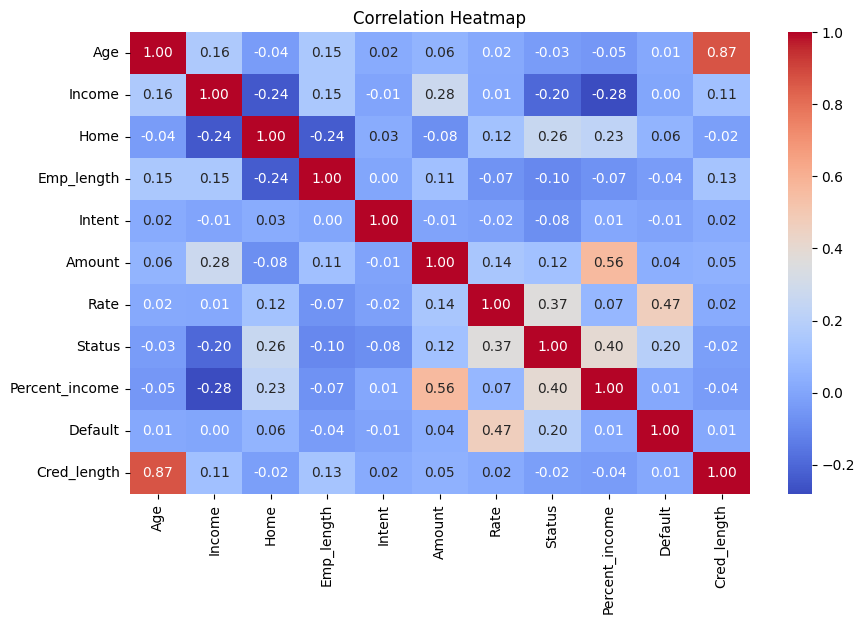

In [16]:
corr_df2 = df_over.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sb.heatmap(corr_df2, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
plt.savefig('charts/correlation_heatmap_oversampled_data.png')
plt.close()

- split the data into features and target variable, scale training sets

In [17]:
scaler = StandardScaler()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

- Model Training

In [18]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(eval_metric='logloss'),
    'LightGBM' : LGBMClassifier(verbose=-1),
    'Decision Tree': DecisionTreeClassifier(),
    'MLPClassifier' : MLPClassifier()
}

In [19]:
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(x_train_scaled, y_train)
    trained_models[name] = model
    print(f'{name} trained.')

Training Logistic Regression...
Logistic Regression trained.
Training Random Forest...
Random Forest trained.
Training Gradient Boosting...
Gradient Boosting trained.
Training XGBoost...
XGBoost trained.
Training LightGBM...
LightGBM trained.
Training Decision Tree...
Decision Tree trained.
Training MLPClassifier...
MLPClassifier trained.


c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


- Model Evaluation

In [20]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(x_test_scaled)
    y_prob = model.predict_proba(x_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC_AUC Score' : roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print(results_df)

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


                 Model  Accuracy  Precision    Recall  F1-Score  ROC_AUC Score
1        Random Forest  0.978999   0.975268  0.982924  0.979081       0.996026
5        Decision Tree  0.944455   0.912402  0.983317  0.946533       0.944455
3              XGBoost  0.921590   0.937653  0.903238  0.920124       0.978686
4             LightGBM  0.884200   0.925081  0.836114  0.878351       0.961046
2    Gradient Boosting  0.842983   0.889806  0.782924  0.832951       0.924965
6        MLPClassifier  0.830913   0.863676  0.785868  0.822937       0.917070
0  Logistic Regression  0.761825   0.762909  0.759764  0.761333       0.840075


In [21]:
for name, model in trained_models.items():
    y_pred = model.predict(x_test_scaled)
    print(name)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.76      0.76      0.76      5095
           1       0.76      0.76      0.76      5095

    accuracy                           0.76     10190
   macro avg       0.76      0.76      0.76     10190
weighted avg       0.76      0.76      0.76     10190

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5095
           1       0.98      0.98      0.98      5095

    accuracy                           0.98     10190
   macro avg       0.98      0.98      0.98     10190
weighted avg       0.98      0.98      0.98     10190

Gradient Boosting
              precision    recall  f1-score   support

           0       0.81      0.90      0.85      5095
           1       0.89      0.78      0.83      5095

    accuracy                           0.84     10190
   macro avg       0.85      0.84      0.84     10190
weighted avg       0.8

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.91      0.94      5095
           1       0.91      0.98      0.95      5095

    accuracy                           0.94     10190
   macro avg       0.95      0.94      0.94     10190
weighted avg       0.95      0.94      0.94     10190

MLPClassifier
              precision    recall  f1-score   support

           0       0.80      0.88      0.84      5095
           1       0.86      0.79      0.82      5095

    accuracy                           0.83     10190
   macro avg       0.83      0.83      0.83     10190
weighted avg       0.83      0.83      0.83     10190



- Confusion Matrix

In [22]:
for name, model in trained_models.items():
    y_pred = model.predict(x_test_scaled)

    conf = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=conf)
    disp.plot()

    plt.title(f'{name} Confusion Matrix')
    plt.savefig(f'charts/confusion_matrix_{name}.png')
    plt.close()

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>